# 🚗 AutoValuate AI — Araç Değerleme & Makine Öğrenmesi Analizi

> **Proje Amacı**: İkinci el araç piyasası verilerinden gelişmiş Özellik Mühendisliği (Feature Engineering) ve Makine Öğrenmesi (SVR, Random Forest) kullanarak aracın anlık piyasa değerini ($) yüksek doğrulukla tahmin etmek.

---
## 📌 1. AŞAMA: Ham Veriyi Yükleme ve İlk İnceleme (Data Inspection)


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik stil ayarları
plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')

# 1. Ham veri setini yükleme
df = pd.read_csv('car_market_dataset.csv')

print('=== VERİ SETİ BOYUTU ===')
print(f'Satır Sayısı: {df.shape[0]}, Sütun Sayısı: {df.shape[1]}')

print('=== EKSİK VERİ KONTROLÜ ===')
print(df.isnull().sum())

df.head()

=== VERİ SETİ BOYUTU ===
Satır Sayısı: 1200, Sütun Sayısı: 9
=== EKSİK VERİ KONTROLÜ ===
brand                  0
model_year             0
mileage_km            10
engine_power_hp       15
engine_capacity_cc     0
fuel_type              0
transmission           0
damage_score           0
price_usd              0
dtype: int64


,brand,model_year,mileage_km,engine_power_hp,engine_capacity_cc,fuel_type,transmission,damage_score,price_usd
0,Ford,2022,52100.0,298.0,3.3,Diesel,Automatic,0,37105.15
1,Audi,2021,52271.0,186.0,2.4,Gasoline,Manual,0,33137.12
2,BMW,2016,100403.0,163.0,2.5,Electric,Manual,0,27580.56
3,Volkswagen,2022,28702.0,204.0,2.3,Hybrid,Automatic,0,38102.75
4,Toyota,2020,40701.0,280.0,3.0,Diesel,Automatic,0,36720.23


---
## 📊 2. AŞAMA: Keşifsel Veri Analizi ve Görselleştirme (Advanced EDA)
Verideki gizli desenleri, aykırı değerleri (Outliers) ve değişkenler arası ilişkileri görselleştiriyoruz.


/var/folders/_z/zct2py195hl84xm77f7xl9b40000gn/T/ipykernel_12456/3688409990.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.values, y=avg_price.index, ax=axes[0, 0], palette='Blues_r')
/var/folders/_z/zct2py195hl84xm77f7xl9b40000gn/T/ipykernel_12456/3688409990.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='price_usd', y='brand', ax=axes[1, 1], palette='Set2')


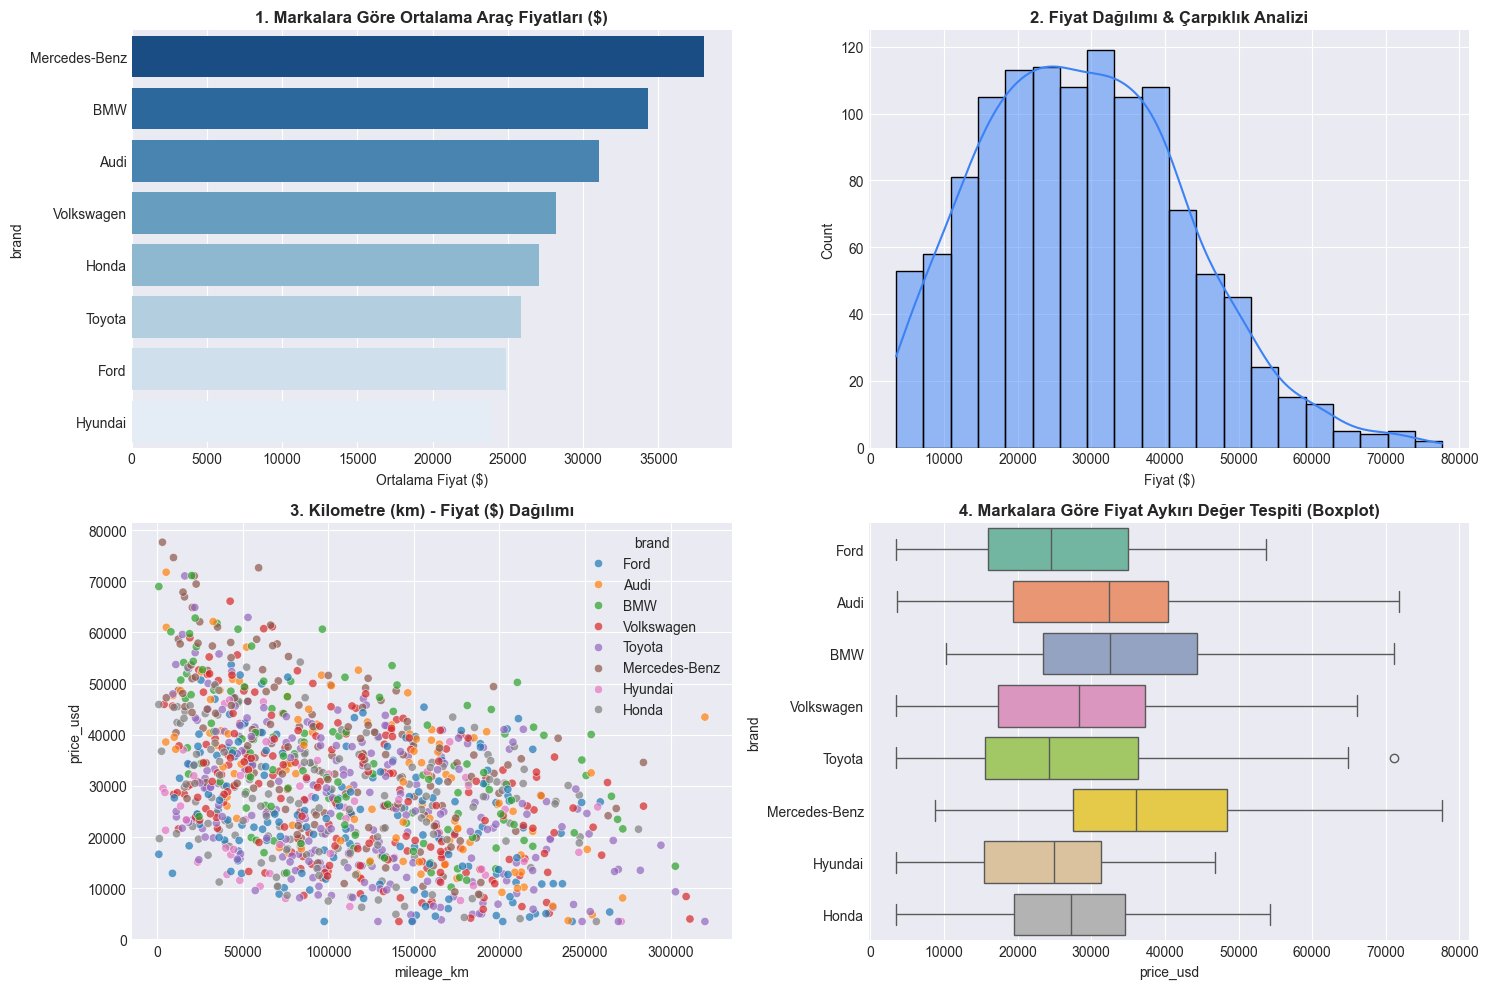

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Markalara Göre Ortalama Fiyat Dağılımı
avg_price = df.groupby('brand')['price_usd'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.values, y=avg_price.index, ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('1. Markalara Göre Ortalama Araç Fiyatları ($)', fontweight='bold')
axes[0, 0].set_xlabel('Ortalama Fiyat ($)')

# 2. Fiyat Dağılımı ve Çarpıklık (Skewness)
sns.histplot(df['price_usd'], kde=True, ax=axes[0, 1], color='#3B82F6')
axes[0, 1].set_title('2. Fiyat Dağılımı & Çarpıklık Analizi', fontweight='bold')
axes[0, 1].set_xlabel('Fiyat ($)')

# 3. Kilometre vs Fiyat İlişkisi
sns.scatterplot(data=df, x='mileage_km', y='price_usd', hue='brand', alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('3. Kilometre (km) - Fiyat ($) Dağılımı', fontweight='bold')

# 4. Markalara Göre Fiyat Kutu Grafiği (Outlier Tespiti)
sns.boxplot(data=df, x='price_usd', y='brand', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('4. Markalara Göre Fiyat Aykırı Değer Tespiti (Boxplot)', fontweight='bold')

plt.tight_layout()
plt.show()

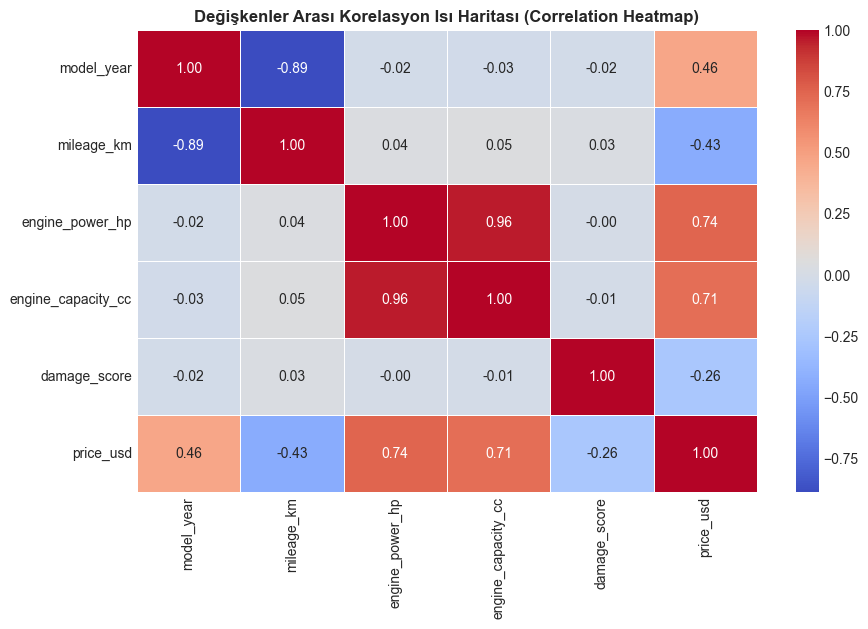

In [42]:
# Değişkenler Arası Korelasyon Isı Haritası
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Değişkenler Arası Korelasyon Isı Haritası (Correlation Heatmap)', fontweight='bold')
plt.show()

---
## 🛠️ 3. AŞAMA: Veri Temizleme ve Özellik Mühendisliği (Feature Engineering)
Eksik verileri gruplayarak dolduruyor ve modelin başarısını artıracak yeni türetilmiş sütunlar ekliyoruz.


In [43]:
# 1. Eksik Verileri Gruplayarak Medyan ile Doldurma
df['engine_power_hp'] = df['engine_power_hp'].fillna(
    df.groupby('brand')['engine_power_hp'].transform('median')
)

df['mileage_km'] = df['mileage_km'].fillna(
    df.groupby('model_year')['mileage_km'].transform('median')
)

# 2. Yeni Akıllı Değişkenler Türetme (Feature Creation)
df['vehicle_age'] = 2025 - df['model_year']
df['km_per_year'] = df['mileage_km'] / (df['vehicle_age'] + 1)
df['hp_per_liter'] = df['engine_power_hp'] / df['engine_capacity_cc']

# 3. Kategorik Değişkenleri Sayısallaştırma (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=['brand', 'fuel_type', 'transmission'], drop_first=True)

print('İşlem Sonrası Kalan Eksik Veri:', df_encoded.isnull().sum().sum())
print('İşlenmiş Veri Tablosu Boyutu:', df_encoded.shape)
df_encoded.head()

İşlem Sonrası Kalan Eksik Veri: 0
İşlenmiş Veri Tablosu Boyutu: (1200, 20)


,model_year,mileage_km,engine_power_hp,engine_capacity_cc,damage_score,price_usd,vehicle_age,km_per_year,hp_per_liter,brand_BMW,brand_Ford,brand_Honda,brand_Hyundai,brand_Mercedes-Benz,brand_Toyota,brand_Volkswagen,fuel_type_Electric,fuel_type_Gasoline,fuel_type_Hybrid,transmission_Manual
0,2022,52100.0,298.0,3.3,0,37105.15,3,13025.0,90.303030,False,True,False,False,False,False,False,False,False,False,False
1,2021,52271.0,186.0,2.4,0,33137.12,4,10454.2,77.500000,False,False,False,False,False,False,False,False,True,False,True
2,2016,100403.0,163.0,2.5,0,27580.56,9,10040.3,65.200000,True,False,False,False,False,False,False,True,False,False,True
3,2022,28702.0,204.0,2.3,0,38102.75,3,7175.5,88.695652,False,False,False,False,False,False,True,False,False,True,False
4,2020,40701.0,280.0,3.0,0,36720.23,5,6783.5,93.333333,False,False,False,False,False,True,False,False,False,False,False


---
## 🤖 4. AŞAMA: Model Eğitimi ve ML Performans Yarışması (Model Tournament)
Veriyi %80 Eğitim ve %20 Test olarak ayırıp modelleri yarıştırıyoruz.


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error

# 1. X ve y ayırımı
X = df_encoded.drop(columns=['price_usd', 'model_year'])
y = df_encoded['price_usd']

# 2. Train-Test Split (%80 - %20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. StandardScaler Ölçeklendirmesi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Modelleri Yarıştırma
models = {
    'Linear Regression': LinearRegression(),
    'Support Vector Regressor (SVR)': SVR(C=2000, epsilon=0.1),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42)
}

print('=== MODEL PERFORMANS YARIŞMASI ===')
print('=' * 60)

best_model = None
best_r2 = -1
best_name = ''

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    print('MODEL:', name)
    print('  -> R2 Skoru (% Dogruluk) :', round(r2*100, 2))
    print('  -> Ortalama Hata (MAE)  : $', round(mae, 2))
    print('-' * 60)
    
    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_name = name

print('SAMPIYON MODEL:', best_name, 'R2:', round(best_r2*100, 2))

=== MODEL PERFORMANS YARIŞMASI ===
MODEL: Linear Regression
  -> R2 Skoru (% Dogruluk) : 94.5
  -> Ortalama Hata (MAE)  : $ 2404.24
------------------------------------------------------------
MODEL: Support Vector Regressor (SVR)
  -> R2 Skoru (% Dogruluk) : 93.27
  -> Ortalama Hata (MAE)  : $ 2209.24
------------------------------------------------------------
MODEL: Random Forest Regressor
  -> R2 Skoru (% Dogruluk) : 90.4
  -> Ortalama Hata (MAE)  : $ 3212.15
------------------------------------------------------------
SAMPIYON MODEL: Linear Regression R2: 94.5


---
## 💾 5. AŞAMA: Şampiyon Modeli ve Scaler'ı Diske Kaydetme (Serialization)
FastAPI Backend servisimizde canlı tahmin yapabilmek için modeli ve ölçeklendiriciyi  olarak kaydediyoruz.


In [45]:
import joblib

# Şampiyon modeli ve scaler'ı kaydet
joblib.dump(best_model, 'car_model_complete.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(X.columns.tolist(), 'feature_columns.joblib')

print('Model, Scaler ve Ozellik Sutunlari basariyla kaydedildi!')
print('  -> car_model_complete.joblib')
print('  -> scaler.joblib')
print('  -> feature_columns.joblib')

Model, Scaler ve Ozellik Sutunlari basariyla kaydedildi!
  -> car_model_complete.joblib
  -> scaler.joblib
  -> feature_columns.joblib
